# Random Forest Modeling

In [ ]:
from sklearn.preprocessing import StandardScaler #statndardize features by removing the mean and scaling to unit variance
from sklearn.model_selection import train_test_split #split arrays or matrices into random train and test subsets
import sys # for manipulating the Python runtime environment
import os # for interacting with the operating system

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd() # Get the current directory

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
# Ensure the parent directory is in sys.path so we can import modules from it
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from field import Field



from data_creator import load_2D
df = load_2D().dropna() # load data from files
#print("Rows before dropna:", load_2D().shape[0])
#print("Rows after dropna:", df.shape[0])
#print(df.isna().sum())

# split data into X and y

X = df[['Area', 'Circumference', 'MU', "Span" ,'CoA','MCS']]#"MCS" and 'CoA' are removed from X temporarily
y = df["AD"] > df["ADPass"]

# # scale X
scale = StandardScaler()
scaled_X = scale.fit_transform(X)

# # train test split
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 4)


In [ ]:

print(df)

             QADate  Unit Energy     MU  DPF  ADPass  RDPass    AD     RD  \
FieldID                                                                     
2401888  12/08/2023  NA12     6X  730.1  400      75      90  97.9  100.0   
2401842  12/08/2023  NA12     6X  264.8  180      75      90  94.6   98.5   
2401965  12/08/2023  NA12     6X  601.7  400      75      90  94.5   99.9   
2401841  12/08/2023  NA12     6X  316.1    0      75      90  96.9   97.7   
2401960  12/08/2023  NA12     6X  587.8  600      75      90  96.8   99.8   
...             ...   ...    ...    ...  ...     ...     ...   ...    ...   
2404678  12/20/2023  EV06     6X  130.0  180      85      95  99.5  100.0   
2403208  12/20/2023  EV06     6X  264.0  250      83      95  96.6   99.9   
2403209  12/20/2023  EV06     6X  267.0  250      83      95  97.0   99.8   
2404652  12/20/2023  EV06     6X  177.0  200      83      95  97.9   99.7   
2404653  12/20/2023  EV06     6X  208.0  200      83      95  98.2   99.4   

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# initialize random forest classifier
rfc = RandomForestClassifier()

# tune random forest parameters
param_grid = {
    'n_estimators':[5,10,15,20],
    'max_depth':[2,5,7,9]
}
grid_clf = GridSearchCV(rfc, param_grid, cv=10)
grid_clf.fit(X_train, y_train)

# fit final random forest model
final = RandomForestClassifier(n_estimators = grid_clf.best_params_["n_estimators"],
 max_depth = grid_clf.best_params_["max_depth"])
final.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, n_estimators=15)

### Results

  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
     |████████████████████████████████| 2.8 MB 5.1 MB/s eta 0:00:01
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Note: you may need to restart the kernel to use updated packages.
Training ROC AUC 1.0


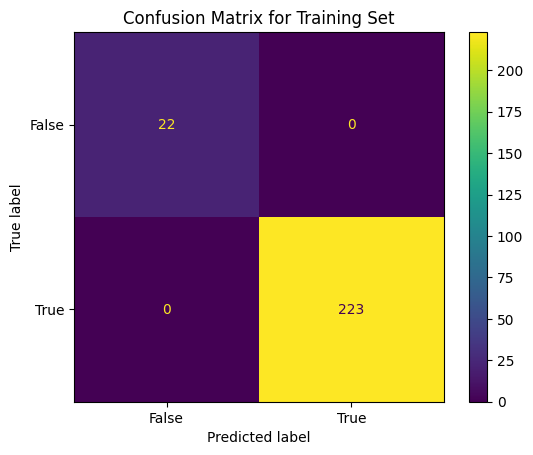

In [ ]:
#%pip install matplotlib

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

pred_rf = final.predict(X_train)

print("Training ROC AUC", roc_auc_score(y_train, pred_rf))
cm1 = ConfusionMatrixDisplay.from_predictions(y_train, pred_rf)
cm1.ax_.set_title("Confusion Matrix for Training Set")
plt.show()

Testing ROC AUC 0.9935064935064934


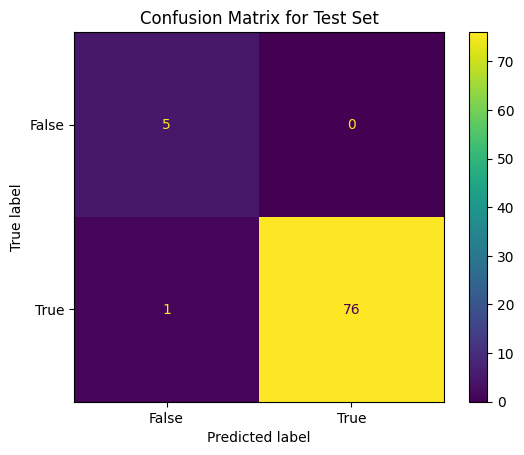

In [6]:

rfc = RandomForestClassifier(n_estimators=10, max_depth=2)
rfc.fit(X_train, y_train)

pred_rf = final.predict(X_test)

print("Testing ROC AUC", roc_auc_score(y_test, pred_rf))
cm1 = ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
cm1.ax_.set_title("Confusion Matrix for Test Set")
plt.show()

In [9]:
import numpy as np
np.save("preds_RF_binary.npy", pred_rf)
np.save("true_RF_binary.npy", y_test)

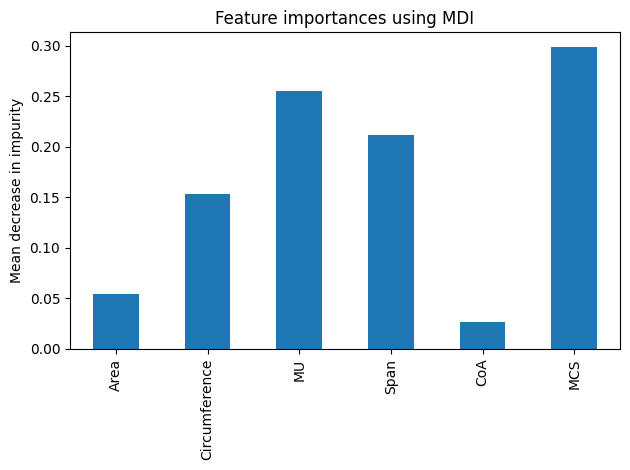

In [ ]:
# Feature Importance
feature_names = X.columns
importances = rfc.feature_importances_

import pandas as pd

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()


#put the results in a table and compare with georges older results